# DNN HW 1


## Handle imports & installs

In [1]:
# !wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
# !unzip data_gsn.zip &> /dev/null
# !rm data_gsn.zip




In [2]:
import torch 
torch.manual_seed(0)

## Prepare the Torch dataframe

In [3]:
from dnn_solver.dataset import IMGDataset


dataset = IMGDataset(train=None)
dataset

Preloaded data shape: torch.Size([10000, 1, 28, 28])


Dataset IMGDataset
    Number of datapoints: 10000
    Root location: ./data

Verify that the images were loaded correctly:

index=1, targets: 
squares: 0 circles: 0 up: 0 right: 5 down: 0 left: 5 


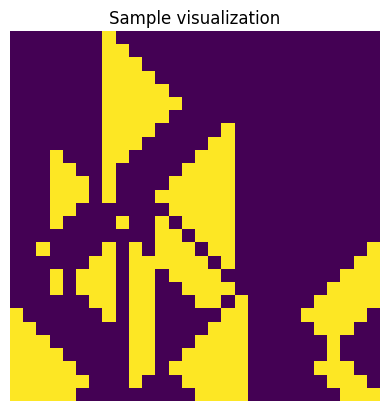

In [4]:
dataset.repr_item(1)

## Data Analysis

We focus on the labels df, verify the distribution of classes etc. 


In [5]:
labels_df = dataset.get_labels()

In [6]:
labels_df.describe()

,squares,circles,up,right,down,left
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.65740,1.714900,1.653000,1.677000,1.685700,1.612000
std,2.62909,2.656073,2.619557,2.627539,2.641101,2.574979
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
max,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000


In [7]:
# assert 1 not in df 
for col in labels_df.columns:
    assert 1 not in labels_df[col].values

It seems the max value for each col is 8, therefore there can be at most 6 * 5 / 2 * 7 = 105 classes represented, not 135 as described in the assignment. This is important because reducing the number of classes 1. reduces loss 2. will not lead to an unexpected behaviour when evaluating on a different dataset that has 1-9 splits. Therefore, we will proceed with the assumption that there should be 105 classes and not 135.

In [8]:
# TODO: use the utils
from dnn_solver.constants import TARGET_COL_NAMES


def get_configuration(row: dict) -> int: 
    #get names of columns that are not 0 
    selected_names = list(filter(lambda x: row[x] > 0, TARGET_COL_NAMES))
    # assert there are two of them 
    assert len(selected_names) == 2, f"Expected 2 non-zero columns, got {row}, selected_names={selected_names}"
    # get their indices 
    indices = list(map(lambda x: TARGET_COL_NAMES.index(x), selected_names))
    # sort the indices 
    indices.sort()
    # calculate the idx 
    idx = 0
    indices = sorted(TARGET_COL_NAMES.index(name) for name in selected_names)
    a, b = indices  # 0 <= a < b < n
    n = len(TARGET_COL_NAMES)
    pair_index = a * (2 * n - a - 1) // 2 + (b - a - 1)  # in [0, 14] for n=6
    idx += pair_index * 7
    idx += row[TARGET_COL_NAMES[indices[0]]] - 2
    return idx 

# Unit test for get_configuration
def make_row(i, j, v):
    """
    Build a row dict with exactly two non-zero columns:
    - column i has count v (2..9)
    - column j has count 2
    """
    row = {name: 0 for name in TARGET_COL_NAMES}
    row[TARGET_COL_NAMES[i]] = v
    row[TARGET_COL_NAMES[j]] = 10 - v
    return row

def test_get_configuration_105_unique_classes():
    seen = set()
    count = 0

    for i in range(len(TARGET_COL_NAMES)):
        for j in range(i + 1, len(TARGET_COL_NAMES)):
            for v in range(2, 9):  # 2..8 (7 values)
                count += 1
                row = make_row(i, j, v)
                cfg = get_configuration(row)

                # config index should live in [0, 120)
                assert 0 <= cfg < 105
                seen.add(cfg)

    # 6 choose 2 = 15 pairs, 15 * 7 = 105
    assert len(seen) == 105, f"Expected 105 unique configurations, got {len(seen)}"
    assert count == 105

test_get_configuration_105_unique_classes()
labels_df['configuration'] = labels_df.apply(get_configuration, axis=1)


array([[<Axes: title={'center': 'configuration'}>]], dtype=object)

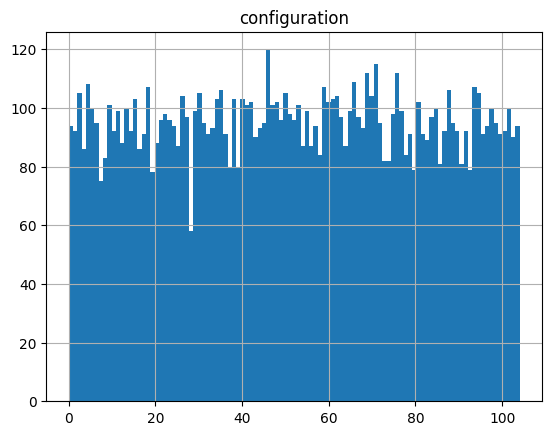

In [9]:
labels_df[['configuration']].hist(bins=105)

In [10]:
config_dist = labels_df["configuration"].value_counts().sort_index()
config_dist.describe()

count    105.000000
mean      95.238095
std        9.364955
min       58.000000
25%       91.000000
50%       95.000000
75%      102.000000
max      120.000000
Name: count, dtype: float64

All of the classes seem to be pretty well represented (except maybe for one, but it still doesn't seem like an issue). Here we've checked for the entire dataset, assuming the train/test split required by the assignment definition was done randomly, the same should hold for the train/test datasets. 

The plotted embeddings are not included in the notebook as they don't really tell any info.
    

## Model setup

In [11]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [12]:
from dnn_solver import DataAugmentation
from torch.utils.data import DataLoader

from dnn_solver.types import DataAugmentationConfig, FlipAugmentationConfig, GaussianNoiseAugmentationConfig, RotationAugmentationConfig


config = DataAugmentationConfig(
    flip=FlipAugmentationConfig(probability=0.1, horizontal=True, vertical=True),
    rotation=RotationAugmentationConfig(probability=0.1),
    gaussian_noise=GaussianNoiseAugmentationConfig(probability=0.1, mean=0.0, std=0.05)
)
# config = DataAugmentationConfig()

train_dataset = IMGDataset(train=True, transform=DataAugmentation(config))
val_dataset   = IMGDataset(train=False)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1000, shuffle=False)


Preloaded data shape: torch.Size([9000, 1, 28, 28])
Preloaded data shape: torch.Size([1000, 1, 28, 28])


In [13]:
from dnn_solver import GSNMultiTaskNet
from dnn_solver import MultiTaskTrainer


model_cls_only = GSNMultiTaskNet()
trainer = MultiTaskTrainer(
    model=model_cls_only,
    trainloader=train_loader,
    testloader=val_loader,
    device=device,
    lambda_cnt=0,  # only classification loss
    # use_cls_loss=False
)


In [14]:
trainer.train(weight_decay=1e-4, patience=10, log_freq=100)

epoch    1, batch   100, loss 4.656
epoch    1 evaluation: loss_total=4.6555, accuracy=0.0060
               loss_cls=4.6555, loss_reg=1.4994
epoch    2, batch   100, loss 4.654
epoch    2 evaluation: loss_total=4.6554, accuracy=0.0060
               loss_cls=4.6554, loss_reg=1.5000
epoch    3, batch   100, loss 4.653
epoch    3 evaluation: loss_total=4.6551, accuracy=0.0160
               loss_cls=4.6551, loss_reg=1.5000
epoch    4, batch   100, loss 4.652
epoch    4 evaluation: loss_total=4.6548, accuracy=0.0160
               loss_cls=4.6548, loss_reg=1.5000
epoch    5, batch   100, loss 4.651
epoch    5 evaluation: loss_total=4.6546, accuracy=0.0160
               loss_cls=4.6546, loss_reg=1.5000
epoch    6, batch   100, loss 4.651
epoch    6 evaluation: loss_total=4.6549, accuracy=0.0160
               loss_cls=4.6549, loss_reg=1.5000
epoch    7, batch   100, loss 4.652
epoch    7 evaluation: loss_total=4.6549, accuracy=0.0160
               loss_cls=4.6549, loss_reg=1.5000
epoch 

KeyboardInterrupt: 

In [ ]:
# import torch
# from dnn_solver.utils import counts_to_config_ids

# def test_aliasing_bug():
#     print("--- Running Class Aliasing Test ---")
    
#     # Create a batch with 2 samples
#     # Index 0 is Squares, Index 1 is Circles
    
#     # Sample A: 4 Squares, 6 Circles (Sum=10)
#     # Sample B: 6 Squares, 4 Circles (Sum=10)
#     target_tensor = torch.tensor([
#         [4, 6, 0, 0, 0, 0],
#         [6, 4, 0, 0, 0, 0]
#     ], dtype=torch.float32)

#     # Use range 1-9 (per your notebook requirements)
#     try:
#         config_ids = counts_to_config_ids(
#             target_tensor, 
#             values_min=1, 
#             values_max=9
#         )
#     except Exception as e:
#         print(f"Function crashed: {e}")
#         return

#     id_a = config_ids[0].item()
#     id_b = config_ids[1].item()

#     print(f"Input A (4 Sq, 6 Ci) -> Class ID: {id_a}")
#     print(f"Input B (6 Sq, 4 Ci) -> Class ID: {id_b}")

#     # The Assertion
#     if id_a == id_b:
#         print("\n[FAIL] ❌ CRITICAL BUG DETECTED")
#         print("Reason: Both configurations were mapped to the exact same Class ID.")
#         print("The model receives contradictory labels for these distinct inputs.")
#     else:
#         print("\n[PASS] ✅ Identities are distinct.")

# # Run the test
# test_aliasing_bug()

--- Running Class Aliasing Test ---
Input A (4 Sq, 6 Ci) -> Class ID: 3
Input B (6 Sq, 4 Ci) -> Class ID: 5

[PASS] ✅ Identities are distinct.
